In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("mymoviedb.csv", lineterminator = '\n') #lineterminator="\n" → each row will end with a new line

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [5]:
df.shape

(9827, 9)

In [6]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [7]:
df.duplicated().sum()
# df.duplicated()

np.int64(0)

In [8]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


# **Exploration Summary:-**

o We have a dataframe consisting of 9827 rows and 9 columns.

o Our dataset looks a bit tidy with no NaNs nor duplicated values.

o Release_Date column needs to be casted into datetime and to extract only the year value.

o Overview, Original_Language and Poster-Url would not be useful during analysis, so we will drop them.

o There is noticable outliers in Popularity Column.

o Vote_Average better be categorical for proper analysis.

o Genre column has comma saperated values and white spaces that needs to be handled and casted into category.

In [9]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


**Data Preprocessing:-**

In [10]:
# converting the Release_Date datatype object(string) to date time

In [11]:
df['Release_Date']= pd.to_datetime(df['Release_Date'])

In [12]:
df['Release_Date']= df['Release_Date'].dt.year

In [13]:
df.info()  # change the Release_Date datatype from object to date time

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   int32  
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int32(1), int64(1), object(5)
memory usage: 652.7+ KB


In [14]:
df.head(5)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


**droping the columns:-**

In [15]:
cols= ['Overview', 'Original_Language', 'Poster_Url']

In [16]:
df.drop(cols, axis=1, inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [17]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


**Categorizing 'Vote_Average' column**

we would cut the **'Vote_Average'** values and make 4 categories: **'Popular'**, **'Average'**, **'Below_Avg'**, **'Not_Popular'** to describe it more using **categorize_col()** function provided above.

In [18]:
def categorize_col(df, col, labels):                # user defined function

    edges = [df[col].describe()['min'],
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]
    df[col]= pd.cut(df[col], edges, labels= labels, duplicates= 'drop')
    return df

In [19]:
labels = ['Not_Popular', 'Below_Avg', 'Average', 'Popular']

categorize_col(df, 'Vote_Average', labels)

df['Vote_Average'].unique()

['Popular', 'Below_Avg', 'Average', 'Not_Popular', NaN]
Categories (4, object): ['Not_Popular' < 'Below_Avg' < 'Average' < 'Popular']

In [20]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,Below_Avg,Thriller
3,2021,Encanto,2402.201,5076,Popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,Average,"Action, Adventure, Thriller, War"


In [21]:
# counting the Vote_Average coulumns 

df['Vote_Average'].value_counts()

Vote_Average
Not_Popular    2467
Popular        2450
Average        2412
Below_Avg      2398
Name: count, dtype: int64

In [22]:
# checking the null in the data
df.isnull().sum()

Release_Date      0
Title             0
Popularity        0
Vote_Count        0
Vote_Average    100
Genre             0
dtype: int64

In [23]:
# droping the null values
df.dropna(inplace=True)

df.isnull().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

# **We'd split genres into a list and then explode our dataframe to have only one genre per row for each movie**

In [24]:
df['Genre'] = df['Genre'].str.split(', ')

df = df.explode('Genre').reset_index(drop = True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


In [25]:
# Casting Genre column into Category

df['Genre'] = df['Genre'].astype('category')

df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


In [27]:
df.nunique()

Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

In [28]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


# **Data Visualization**

In [29]:
sns.set_style('whitegrid')  # show the visuals with White background & Light grid lines behind the chart

# *What is the most frequent genre of movies released on Netflix?*

In [30]:
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

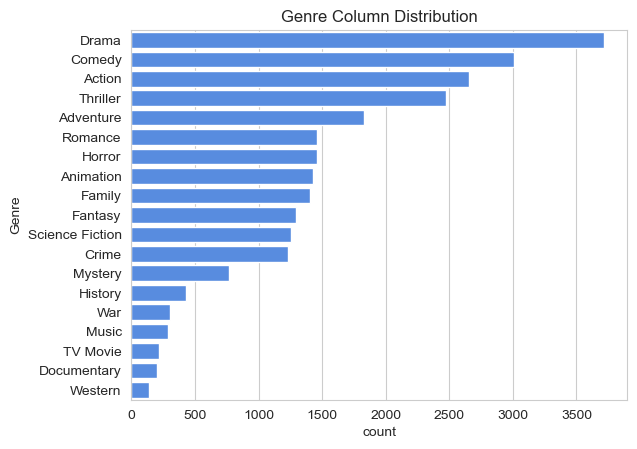

In [31]:
sns.countplot(y='Genre', data=df, order= df['Genre'].value_counts().index,
           color= '#4287f5')
plt.title("Genre Column Distribution")
plt.show()

# *Which has highest votes in vote avg column?*

In [32]:
highest_votes = df.groupby(['Vote_Average'])['Vote_Count'].count().sort_values(ascending=False)

C:\Users\Rahul.user\AppData\Local\Temp\ipykernel_11720\221504211.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  highest_votes = df.groupby(['Vote_Average'])['Vote_Count'].count().sort_values(ascending=False)


In [33]:
highest_votes

Vote_Average
Average        6613
Popular        6520
Below_Avg      6348
Not_Popular    6071
Name: Vote_Count, dtype: int64

<Axes: ylabel='Vote_Average'>

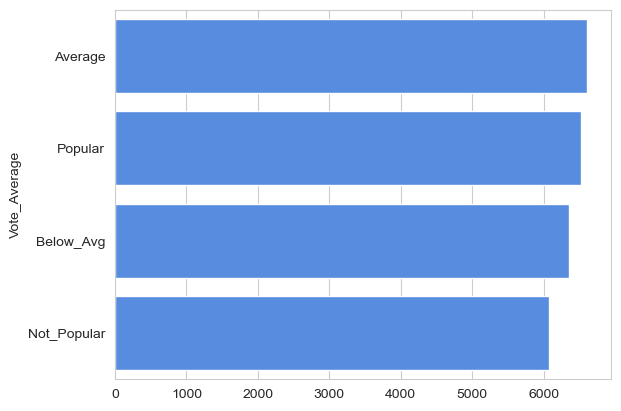

In [34]:
sns.barplot(x=highest_votes.values, y=highest_votes.index, order=highest_votes.index ,
            color='#4287f5')

In [35]:
# Another Answer of same question

# sns.countplot(y='Vote_Average', data=df, order= df['Vote_Average'].value_counts().index, color= '#4287f5')
# plt.title("Vote Distribution")
# plt.show()

# *What movie got the highest popularity? what's it's genre*

In [36]:
df.head(2)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure


In [37]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction


# *What movie got the lowest popularity? what's it's genre*

In [38]:
df[df['Popularity']== df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,Average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,Average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,Average,History
25549,1984,Threads,13.354,186,Popular,War
25550,1984,Threads,13.354,186,Popular,Drama
25551,1984,Threads,13.354,186,Popular,Science Fiction


# *Which year has the most filmmed movies*

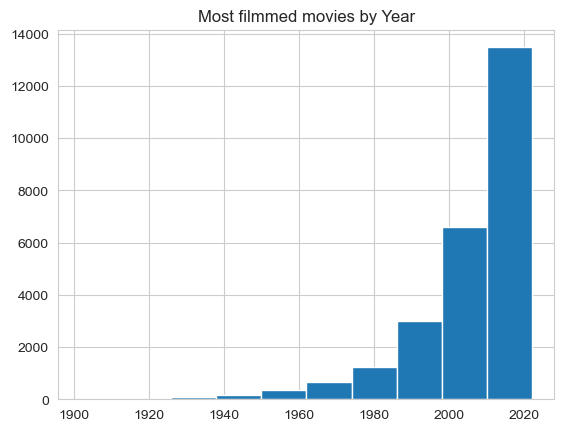

In [39]:
df['Release_Date'].hist()
plt.title("Most filmmed movies by Year")
plt.show()

# *Conclusion*

Q1: What is the most frequent genre in the dataset?

From the analysis, Drama appears to be the most common genre in the dataset. It accounts for more than 14% of the movies among the 19 different genres, making it the most frequently occurring category.

-----

Q2: Which genre has the highest number of votes?

Around 25.5% of the movies (6520 rows) in the dataset have a high vote count. Among these, Drama once again stands out, receiving the highest level of popularity among viewers, contributing to more than 18.5% of the overall popularity share.

---------

Q3: Which movie has the highest popularity and what is its genre?

Based on the dataset, Spider-Man: No Way Home has the highest popularity score. The movie belongs to the genres Action, Adventure, and Science Fiction.

------

Q4: Which movie has the lowest popularity and what is its genre?

The movie “The United States Thread” shows the lowest popularity score in the dataset. It falls under multiple genres including Music, Drama, War, Sci-Fi, and History.

------

Q5: Which year has the highest number of filmed movies?

After examining the yearly distribution, 2020 recorded the highest number of movies produced in this dataset.

# **🎬 ML Project: Personalized Movie Recommendation System**

In [40]:
# saving the cleaned movies.csv file

df.to_csv("cleaned_data.csv", index=False, lineterminator='\n')

In [41]:
# Load Dataset
df = pd.read_csv("cleaned_data.csv")

# df.columns = df.columns.str.replace('\r', '')

In [42]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


In [43]:
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors

# *using Label Encoder to convert Genre and Vote_Average to  Numbers*

In [44]:
le = LabelEncoder()
df['Genre_encoded']= le.fit_transform(df['Genre'])

In [45]:
# le = LabelEncoder()
df['Vote_Avg_encoded'] = le.fit_transform(df['Vote_Average'])

In [46]:
df['Genre_encoded'].head(5)

0     0
1     1
2    14
3     4
4    12
Name: Genre_encoded, dtype: int64

In [47]:
df['Vote_Avg_encoded'].head(5)

0    3
1    3
2    3
3    3
4    3
Name: Vote_Avg_encoded, dtype: int64

In [48]:
df.head(5)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Genre_encoded,Vote_Avg_encoded
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action,0,3
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure,1,3
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction,14,3
3,2022,The Batman,3827.658,1151,Popular,Crime,4,3
4,2022,The Batman,3827.658,1151,Popular,Mystery,12,3


# *Selects Features from the data*

In [49]:
features = df[['Genre_encoded','Popularity','Vote_Avg_encoded']]

# *Training the Model*

NearestNeighbors (KNN) finds similar movies

In [60]:
model = NearestNeighbors(n_neighbors=6, metric='cosine')

model.fit(features)

NearestNeighbors(metric='cosine', n_neighbors=6)

# *Creating Recommendation Function*

In [63]:
def recommend_movie(movie_name):
    movie_index = df[df['Title']==movie_name].index[0]

    distances, indices = model.kneighbors([features.iloc[movie_index]])

    for i in indices[0][:]:
        print(df.iloc[i]['Title'])

# *Testing Recommendation*

In [65]:
recommend_movie("The King's Man")

Infernal Affairs III
Mad Max
Dawn of the Dead
Promare
Naruto: The Lost Story - Mission: Protect the Waterfall Village!
Crime Busters


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


# *Project Summary – Movie Recommendation System*

o In this project, a movie recommendation system was developed to suggest similar movies based on their characteristics. The dataset was first preprocessed using Python and machine learning libraries from scikit-learn.

o To prepare the data, the Genre and Vote_Average column was converted into numerical values using the LabelEncoder, allowing the machine learning model to process categorical information. Relevant features such as Genre, Popularity, and Vote Average were selected to represent each movie.

o The recommendation model was built using the K-Nearest Neighbors approach through the NearestNeighbors algorithm. This model measures similarity between movies using the cosine similarity metric, which compares feature vectors to identify movies with similar patterns.

o When a user inputs a movie title, the system finds the closest movies in the dataset based on the selected features and returns the top 5 most similar movie recommendations. This approach helps users discover movies with similar genres, popularity levels, and ratings.

o Overall, the project demonstrates how machine learning techniques can be used to build a basic personalized recommendation system, which is commonly used in platforms like movie streaming and e-commerce services.